In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ROOT_PATH = "/rds/general/user/yl9422/home/files/M4R-Elly/StatQA/SCRC/outputs/step2/"
train_labels = pd.read_csv("" + ROOT_PATH + "llama3_8b_train_labels.csv")
train_logits = pd.read_csv("" + ROOT_PATH + "llama3_8b_train_logits.csv")
train_probs = 1.0 / (1.0 + np.exp(-train_logits))
calib_labels = pd.read_csv("" + ROOT_PATH + "llama3_8b_calib_labels.csv")
calib_logits = pd.read_csv("" + ROOT_PATH + "llama3_8b_calib_logits.csv")
calib_probs = 1.0 / (1.0 + np.exp(-calib_logits))
test_labels = pd.read_csv("" + ROOT_PATH + "llama3_8b_test_labels.csv")
test_logits = pd.read_csv("" + ROOT_PATH + "llama3_8b_test_logits.csv")
test_probs = 1.0 / (1.0 + np.exp(-test_logits))

train_labels_T = train_labels.T
train_logits_T = train_logits.T
calib_labels_T = calib_labels.T
calib_logits_T = calib_logits.T
test_labels_T = test_labels.T
test_logits_T = test_logits.T

In [ ]:
def losses(scores, labels, lmbd, loss):
    preds = (scores > lmbd).astype(int)

    TP = (preds * labels).sum(axis=1)
    FP = (preds * (1 - labels)).sum(axis=1) # 多选
    FN = ((1 - preds) * labels).sum(axis=1) # 少选
    TN = ((1 - preds) * (1 - labels)).sum(axis=1)

    if loss == 'FNR': # False Negative Rate 少选/正确答案
        FNR = FN / (TP + FN)
        return FNR
    
    elif loss == 'FDR': # False Discovery Rate 多选/预测答案
        FDR = FP / (TP + FP)
        return FDR
    
    elif loss == '1-Jaccard':
        Jaccard = TP / (TP + FP + FN)
        return 1 - Jaccard

    elif loss == '1-F1':
        F1 = 2 * TP / (2 * TP + FP + FN)
        return 1 - F1

    elif loss == '1-EM': # Exact Match
        exact_match = (preds == labels).all(axis=1).astype(int)
        return 1 - exact_match
    
def crc_calib(calib_scores, calib_labels, alpha=0.1, loss='FNR', n_grid=1000):
    n = len(calib_scores)
    risk_threshold = alpha - (1.0 - alpha) / n        # 增广风险上界

    max_score = calib_scores.max().max()
    min_score = calib_scores.min().min()
    for lmbd in np.linspace(max_score, min_score, n_grid + 1):
        mean_loss = losses(scores=calib_scores,  labels=calib_labels, lmbd=lmbd, loss=loss).mean()
        if mean_loss <= risk_threshold:
            return lmbd
    return max_score

def evaluate(test_scores, test_labels, lmbd, loss='FNR'):
    test_losses    = losses(scores=test_scores,  labels=test_labels, lmbd=lmbd, loss=loss)
    set_sizes = ((test_scores > lmbd).astype(int) * test_labels).sum(axis=1) + ((test_scores > lmbd).astype(int) * (1 - test_labels)).sum(axis=1)

    print(f"λ̂               : {lmbd}")
    print(f"Test loss mean  : {test_losses.mean():.4f}")
    print(f"Test loss std   : {test_losses.std():.4f}")
    print(f"Test loss=0 rate     : {(test_losses == 0).mean():.4f}")   # FNR=0 的比例
    print(f"Test mean set size   : {set_sizes.mean():.2f}")

def plot_calib(calib_scores, calib_labels, test_scores, test_labels, lmbd_hat, loss='FNR'):
    lmbds = np.linspace(calib_scores.max().max(), calib_scores.min().min(), 1000 + 1)
    calib_losses = [losses(scores=calib_scores,  labels=calib_labels, lmbd=lmbd, loss=loss).mean() for lmbd in lmbds]
    test_losses  = [losses(scores=test_scores,  labels=test_labels,  lmbd=lmbd, loss=loss).mean() for lmbd in lmbds]
    calib_loss = losses(scores=calib_scores,  labels=calib_labels, lmbd=lmbd_hat, loss=loss).mean()
    test_loss = losses(scores=test_scores,  labels=test_labels, lmbd=lmbd_hat, loss=loss).mean()

    plt.plot(lmbds, calib_losses, label=f'Calib {loss}')
    plt.plot(lmbds, test_losses, label=f'Test {loss}')
    plt.axvline(x=lmbd_hat, color='red', linestyle='--', label=f'λ_hat={lmbd_hat:.4f}')
    plt.axhline(y=calib_loss, color='blue', linestyle='--', label=f'Calib {loss} at λ_hat = {calib_loss:.4f}')
    plt.axhline(y=test_loss, color='green', linestyle='--', label=f'Test {loss} at λ_hat = {test_loss:.4f}')
    plt.xlabel('λ')
    plt.ylabel(loss)
    plt.title(f'Calibrated Risk Control (CRC) - {loss}')
    plt.legend()
    plt.grid()
    plt.show()

4.065426065600002


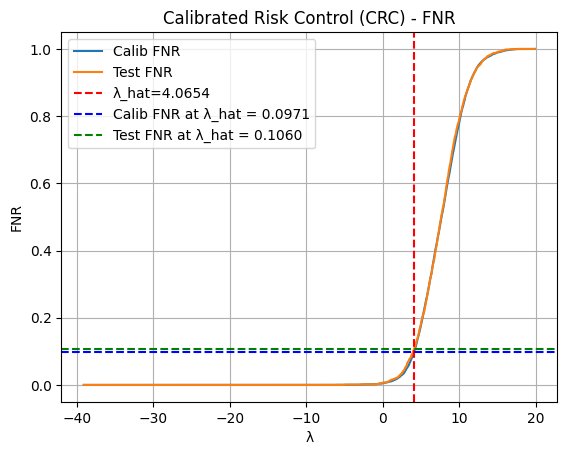

In [ ]:
alpha = 0.1
loss = 'FNR'
lmbd_hat = crc_calib(calib_logits, calib_labels, alpha, loss)
print(lmbd_hat)
evaluate(test_scores=test_logits, test_labels=test_labels, lmbd=lmbd_hat, loss=loss)
plot_calib(calib_logits, calib_labels, test_logits, test_labels, lmbd_hat, loss)

In [9]:
from scipy.special import logsumexp
calib_energy = logsumexp(calib_logits, axis=1)

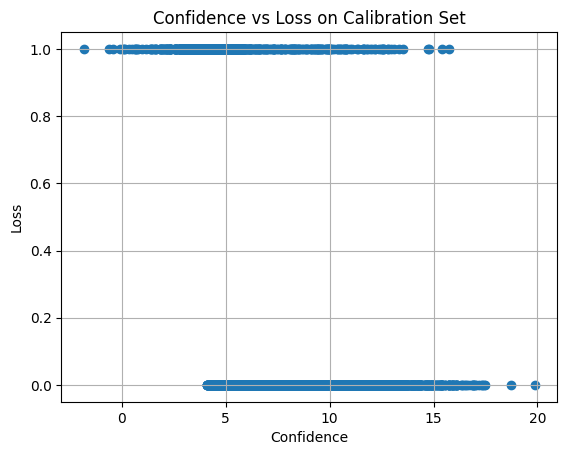

In [10]:
eps = 1e-8
calib_neg_entropies = np.sum(
    calib_probs * np.log(calib_probs + eps) + (1 - calib_probs) * np.log(1 - calib_probs + eps), 
    axis=1
)

calib_losses = losses(calib_logits, calib_labels, lmbd=4.065, loss='NEM')
# plot calib_neg_entropies and EM
plt.scatter(calib_energy, calib_losses)
plt.xlabel('Confidence')
plt.ylabel('Loss')
plt.title('Confidence vs Loss on Calibration Set')
plt.grid()
